In [21]:
import timesfm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm 
import os 
from itertools import product
from collections import defaultdict
import time

from timesfm_functions import (
    TimesFMModel,
    load_aluminium_data,
    calculate_prediction_metrics,
)

from functions import line_plot, pred_value_to_char, find_n_best_features

In [22]:
def get_batched_data_fn(df, batch_size, context_len, horizon_len, static=True, features=None):
    examples = defaultdict(list)
    sub_df = df.iloc[horizon_len:, :].reset_index(drop=True)
    N = len(sub_df)

    vol_col = f"{pred_value_to_char(horizon_len)}_vol"
    if vol_col not in sub_df.columns:
        raise KeyError(f"Column '{vol_col}' not found in sub_df")

    if features is None:
        candidates = find_n_best_features(expiry=horizon_len, n=20)
    else:
        candidates = list(features)

    covs = [c for c in candidates if c in sub_df.columns]
    if not covs:
        print("[warn] no covariates found in dataframe; only vanilla predictions will differ.")

    for start in range(0, N - (context_len + horizon_len) + 1, 1):
        context_end = start + context_len
        examples["inputs"].append(sub_df[vol_col].iloc[start:context_end].to_list())

        if static:
            idx = context_end - 1
            for cov in covs:
                examples[cov].append(float(sub_df[cov].iat[idx]))
        else:
            for cov in covs:
                examples[cov].append(sub_df[cov].iloc[start:context_end].to_list())

    num_examples = len(examples["inputs"])

    def data_fn():
        for i in range(0, num_examples, batch_size):
            yield {k: v[i:i + batch_size] for k, v in examples.items()}

    return data_fn

def _last_step(x):
    arr = np.asarray(x)
    if arr.ndim != 2:
        raise ValueError(f"Forecast must be 2D (batch, horizon), got {arr.shape}")
    return arr[:, -1].astype(float).tolist()

def _freq_list(freq, batch_size):
    if isinstance(freq, int):
        return [freq] * batch_size
    if isinstance(freq, (list, tuple, np.ndarray)):
        if len(freq) == 1:
            return [int(freq[0])] * batch_size
        if len(freq) == batch_size:
            return list(map(int, freq))
        raise ValueError(f"'freq' length {len(freq)} != batch size {batch_size}")
    raise TypeError(f"Unsupported freq type: {type(freq)}")

def _filter_dynamic_features(example, feature_names, batch_size, expected_len):
    """Keep only dynamic features that exist and have shape (batch_size, expected_len) with finite values."""
    keep = {}
    for name in feature_names:
        if name not in example:
            continue
        seqs = example[name]  # list of length batch_size; each seq length = expected_len
        if len(seqs) != batch_size:
            continue
        ok = True
        for s in seqs:
            a = np.asarray(s, dtype=float)
            if a.ndim != 1 or a.shape[0] != expected_len or not np.isfinite(a).all():
                ok = False
                break
        if ok:
            keep[name] = seqs
    return keep

def _filter_static_features(example, feature_names, batch_size):
    """Keep only static features that exist and provide batch_size finite scalars."""
    keep = {}
    for name in feature_names:
        if name not in example:
            continue
        vals = example[name]
        if len(vals) != batch_size:
            continue
        a = np.asarray(vals, dtype=float)
        if not np.isfinite(a).all():
            continue
        keep[name] = a.tolist()
    return keep

def run_inference(model, input_data, expiry, top_n, freq, static=True, features=None,
                  context_len=None, horizon_len=None):
    """
    Pass context_len and horizon_len if you want dynamic-length checks; otherwise deduced from first batch.
    """
    if features is None:
        features = list(find_n_best_features(expiry=expiry, n=top_n))

    vanilla_forecasts, covariate_forecasts = [], []

    first = True
    for example in input_data():
        bsz = len(example["inputs"])
        f_list = _freq_list(freq, bsz)

        # vanilla
        raw_forecast, _ = model.predict(inputs=example["inputs"], freq=f_list)

        # infer expected dynamic length on first batch if not provided
        if first and horizon_len is None:
            # assume inputs are length context_len; we can infer it:
            inferred_ctx = len(example["inputs"][0])
            context_len = inferred_ctx if context_len is None else context_len
            # TimesFM horizon is set by model expiry; we can infer from raw_forecast shape:
            inferred_hzn = np.asarray(raw_forecast).shape[1]
            horizon_len = inferred_hzn if horizon_len is None else horizon_len
            first = False

        expected_dyn_len = (context_len or 0) + (horizon_len or 0)

        if static:
            static_num = _filter_static_features(example, features, bsz)
            if static_num:
                cov_forecast, _ols = model.predict_with_covariates(
                    inputs=example["inputs"],
                    dynamic_numerical_covariates={},
                    dynamic_categorical_covariates={},
                    static_numerical_covariates=static_num,
                    static_categorical_covariates={},
                    freq=f_list,
                    xreg_mode="xreg + timesfm",
                    ridge=0.0,
                    force_on_cpu=False,
                    normalize_xreg_target_per_input=True,
                )
            else:
                cov_forecast = raw_forecast  # no valid covariates -> skip to avoid log2(0)
        else:
            dyn_num = _filter_dynamic_features(example, features, bsz, expected_dyn_len)
            if dyn_num:
                cov_forecast, _ols = model.predict_with_covariates(
                    inputs=example["inputs"],
                    dynamic_numerical_covariates=dyn_num,
                    dynamic_categorical_covariates={},
                    static_numerical_covariates={},
                    static_categorical_covariates={},
                    freq=f_list,
                    xreg_mode="xreg + timesfm",
                    ridge=0.0,
                    force_on_cpu=False,
                    normalize_xreg_target_per_input=True,
                )
            else:
                cov_forecast = raw_forecast  # no valid covariates -> skip

        vanilla_forecasts.extend(_last_step(raw_forecast))
        covariate_forecasts.extend(_last_step(cov_forecast))

    return vanilla_forecasts, covariate_forecasts




def get_cosine_data(n=2440):
    return pd.DataFrame({'1w_vol': np.cos(np.linspace(0, 2*np.pi, n, endpoint=False)).tolist()})

# df = get_cosine_data()

def plotting_fn(df, vanilla_forecasts, covariate_forecasts, horizon_len):
    pred_van = vanilla_forecasts[-250:]
    pred_cov = covariate_forecasts[-250:]
    test_true = df[f'{pred_value_to_char(horizon_len)}_vol'][-250:].tolist()

    ax, fig = line_plot(pred_van, pred_van, 'pred_van', show=False)
    ax, fig = line_plot(pred_cov, pred_cov, 'pred_cov', ax=ax, linecolor='green', show=False)
    _, fig = line_plot(test_true, test_true, 'test', ax=ax, linecolor='red', show=False)

    return pred_van, pred_cov, test_true, fig

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 12221.17it/s]


{'MAPE': np.float64(49.5445894621844),
 'MAE': 0.07557500593692544,
 'RMSE': 0.09618707511907046,
 'MSE': 0.009251953419961705,
 'MASE': np.float64(2.3026257095669886)}

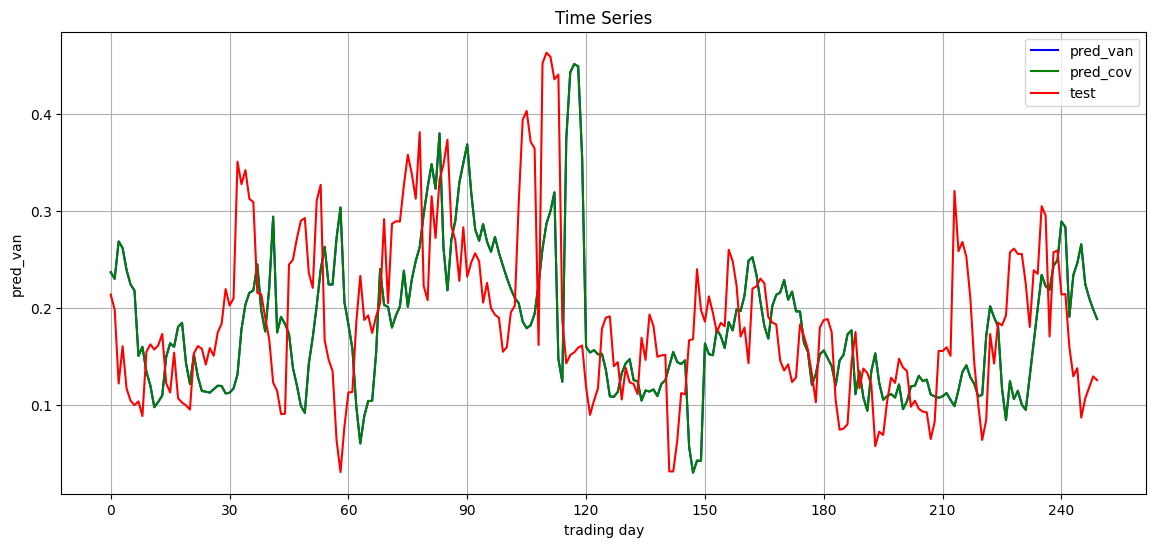

In [24]:
df = load_aluminium_data()

batch_size   = 128
horizon_len  = 5
context_len  = 32
freq         = 1
top_n        = 5
static       = True
positional_embedding = False
features = list(find_n_best_features(expiry=horizon_len, n=top_n))

model = TimesFMModel(expiry=horizon_len, context_length=context_len, positional_embedding=positional_embedding)
input_data = get_batched_data_fn(df, batch_size=batch_size, context_len=context_len, horizon_len=horizon_len, static=static, features=features)

vanilla_forecasts, covariate_forecasts = run_inference(
    model=model, input_data=input_data, expiry=horizon_len,
    top_n=top_n, freq=freq, static=static, features=features
)

pred_van, pred_cov, test_true, fig = plotting_fn(df=df, vanilla_forecasts=vanilla_forecasts,
            covariate_forecasts=covariate_forecasts, horizon_len=horizon_len)

calculate_prediction_metrics(pred_van, test_true)

calculate_prediction_metrics(pred_cov, test_true)

In [ ]:
calculate_prediction_metrics(pred_van, test_true)

{'MAPE': np.float64(33.6239027369619),
 'MAE': 0.06862440842615515,
 'RMSE': 0.08413572209525086,
 'MSE': 0.007078819732489283,
 'MASE': np.float64(28.74014132917583)}

In [ ]:
calculate_prediction_metrics(pred_cov, test_true)

{'MAPE': np.float64(33.62391471475729),
 'MAE': 0.06862441640194775,
 'RMSE': 0.08413566707959952,
 'MSE': 0.007078810474929206,
 'MASE': np.float64(28.740144669465558)}

In [ ]:
# --- data & grids ---
df = load_aluminium_data()

batch_size = 128
horizon_grid = [5, 22, 66, 252]
context_grid = [32, 64, 128, 256, 512, 1024]
freq_grid = [0, 1, 2]
topn_grid = [1, 3, 5, 10, 20]
static = True
pos_embed_grid = [True, False]

# --- output dirs ---
root_dir = "timesfm_zeroshot_all_results"
metrics_dir = os.path.join(root_dir, "metrics")
plots_dir = os.path.join(root_dir, "plots")
os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

for expiry in horizon_grid:
    rows = []
    metrics_csv = os.path.join(metrics_dir, f"metrics_expiry_{expiry}.csv")

    for pos_emb in pos_embed_grid:
        for window_size in context_grid:
            if window_size < expiry:
                continue

            model = TimesFMModel(
                expiry=expiry,
                context_length=window_size,
                positional_embedding=pos_emb
            )

            for f in freq_grid:
                # -------- VANILLA (top_n = 0) --------
                input_data_van = get_batched_data_fn(
                    df,
                    batch_size=batch_size,
                    context_len=window_size,
                    horizon_len=expiry,
                    static=static,
                    features=[],
                )

                vanilla_forecasts, _ = run_inference(
                    model=model,
                    input_data=input_data_van,
                    expiry=expiry,
                    top_n=0,
                    freq=f,
                    static=static,
                    features=[]
                )

                pred_van, _, test_true, fig_van = plotting_fn(
                    df=df,
                    vanilla_forecasts=vanilla_forecasts,
                    covariate_forecasts=vanilla_forecasts,   # just to plot a single line
                    horizon_len=expiry
                )
                fig_van.savefig(
                    os.path.join(plots_dir, f"vanilla_exp{expiry}_win{window_size}_freq{f}_pos{int(pos_emb)}.png"),
                    dpi=150, bbox_inches="tight"
                )
                plt.close(fig_van)

                m = calculate_prediction_metrics(pred_van, test_true)
                rows.append({
                    "expiry": expiry,
                    "window_size": window_size,
                    "top_n": 0,
                    "freq": f,
                    "positional_embedding": pos_emb,
                    "mape": float(m["MAPE"]),
                    "mae":  float(m["MAE"]),
                    "rmse": float(m["RMSE"]),
                    "mse":  float(m["MSE"]),
                    "mase": float(m["MASE"]),
                })

                # -------- COVARIATES (top_n in grid) --------
                for top_n in topn_grid:
                    feats = list(find_n_best_features(expiry=expiry, n=top_n))

                    input_data_cov = get_batched_data_fn(
                        df,
                        batch_size=batch_size,
                        context_len=window_size,
                        horizon_len=expiry,
                        static=static,
                        features=feats,
                    )

                    vanilla_forecasts_cov, covariate_forecasts = run_inference(
                        model=model,
                        input_data=input_data_cov,
                        expiry=expiry,
                        top_n=top_n,
                        freq=f,
                        static=static,
                        features=feats
                    )

                    pred_van2, pred_cov, test_true2, fig_cov = plotting_fn(
                        df=df,
                        vanilla_forecasts=vanilla_forecasts_cov,
                        covariate_forecasts=covariate_forecasts,
                        horizon_len=expiry
                    )
                    fig_cov.savefig(
                        os.path.join(plots_dir, f"cov_exp{expiry}_win{window_size}_freq{f}_top{top_n}_pos{int(pos_emb)}.png"),
                        dpi=150, bbox_inches="tight"
                    )
                    plt.close(fig_cov)

                    mc = calculate_prediction_metrics(pred_cov, test_true2)
                    rows.append({
                        "expiry": expiry,
                        "window_size": window_size,
                        "top_n": top_n,
                        "freq": f,
                        "positional_embedding": pos_emb,
                        "mape": float(mc["MAPE"]),
                        "mae":  float(mc["MAE"]),
                        "rmse": float(mc["RMSE"]),
                        "mse":  float(mc["MSE"]),
                        "mase": float(mc["MASE"]),
                    })

    pd.DataFrame(rows, columns=[
        "expiry","window_size","top_n","freq","positional_embedding","mape","mae","rmse","mse","mase"
    ]).to_csv(metrics_csv, index=False)
